# Testing loader

In [1]:
# testing loader
from src.ingest import ingest

docs = ingest(path = 'data')
print(docs)

[Document(metadata={'source': 'data\\test.txt'}, page_content='Capstone Project Requirement Document\nEnterprise Knowledge Assistant\n1. Project Overview\nProject Name: Enterprise Knowledge Assistant\n\nProject Description (One-Liner):\nA multi-agent Retrieval-Augmented Generation (RAG) system that answers employee queries using enterprise documents with source citations.\n\nThis capstone project is intended for an individual developer with basic knowledge of Python, Generative AI, and Agentic AI. The objective is to build an enterprise-ready knowledge assistant that demonstrates agent orchestration, document retrieval, and trustworthy AI through citations.\n2. Objectives and Learning Outcomes\nObjectives:\n- Build a multi-agent RAG workflow using LangChain or LangGraph\n- Implement semantic document retrieval using a Vector Database\n- Generate accurate, cited responses using an LLM\n- Expose the system via a simple API or UI'), Document(metadata={'source': 'data\\test.txt'}, page_con

# Testing Retriever

In [2]:
from src.vector_store import __vector_store
__vector_store

In [3]:
from src.vector_store import retrieve_docs
retrieve_tool = retrieve_docs
retrieve_tool.invoke("tell me a joke on humans")

'- Explainable and grounded responses\n- Modular, agent-based architecture\n- Config-driven embeddings, models, and thresholds\n- Suitable for local or demo-scale deployment\n5. High-Level Architecture\nThe Enterprise Knowledge Assistant follows a multi-agent RAG architecture orchestrated using LangGraph or LangChain.Retrieved Documents: \n\nLearning Outcomes:\n- Understanding multi-agent coordination patterns\n- Practical experience with enterprise-grade RAG systems\n- Skills in explainability, grounding, and citation handling\n3. Functional Requirements\n- Ingest and index enterprise documents (PDF, DOCX, TXT)\n- Chunk and embed documents into a vector store\n- Accept natural language employee queries\n- Retrieve relevant document chunks using similarity search\n- Orchestrate agents for retrieval, reasoning, and citation\n- Generate answers with explicit source citations\n- Provide API or UI access to the assistant\n- Log queries, sources, and responses\n4. Non-Functional Requirement

In [4]:
from langgraph.graph import MessagesState
from typing import List
from langchain_core.documents import Document
from langchain.messages import HumanMessage

class RAGState(MessagesState):
    question: str
    documents: List[Document]

In [5]:
state = RAGState(messages= [HumanMessage(content= 'test message')], question = 'dummy', documents= [])

In [6]:
state['messages']

[HumanMessage(content='test message', additional_kwargs={}, response_metadata={})]

In [2]:
from langchain_openai import ChatOpenAI
from src.ragState import RAGState
from src.vector_store import retrieve_docs
from langchain.messages import HumanMessage
def generate_response(state: RAGState):
    llm = ChatOpenAI()
    llm_with_tools = llm.bind_tools([retrieve_docs])
    response = llm_with_tools.invoke(input = state['messages'])
    return response
init_state = RAGState(messages= [HumanMessage(content = 'Hi')],
                           documents=None,
                           answer= None)
print(f"Previous state: {init_state}")
op = generate_response(init_state)

print(op)

Previous state: {'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})], 'documents': None, 'answer': None}
content='Hello! How can I assist you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 47, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E0Td1wq5pf7UXdTh8zU1wuqcE6ZBo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f51ba-5945-7953-8210-c95c9a1edd44-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 10, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_det

In [ ]:
from src.generate_or_call_tool import generate_response
init_state = RAGState(messages= [HumanMessage(content = 'Can you tell me about capstone project?')],
                           documents=None,
                           answer= None)
print(f"Previous state: {init_state}")
response = generate_response(state = init_state)
print(f"Updated state: {response}")

Previous state: {'messages': [HumanMessage(content='Can you tell me about capstone project?', additional_kwargs={}, response_metadata={})], 'documents': None, 'answer': None}
Updated state: {'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 55, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E0UQF1wLpj9GflY3xWENc8IoRA0hR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f51e8-ea0d-7853-b9b7-c406aee425db-0', tool_calls=[{'name': 'retrieve_docs', 'args': {'query': 'capstone project'}, 'id': 'call_9XMYIjzJozAJCUYYj4L2L7qw', 'type': 'tool_cal

In [7]:
init_state

{'messages': [HumanMessage(content='Can you tell me about capstone project?', additional_kwargs={}, response_metadata={})],
 'documents': None,
 'answer': None}

In [27]:
response['messages'].tool_calls

[{'name': 'retrieve_docs',
  'args': {'query': 'capstone project'},
  'id': 'call_9XMYIjzJozAJCUYYj4L2L7qw',
  'type': 'tool_call'}]

# Building Graph

In [4]:
from langgraph.graph import StateGraph, START, END
from src.ragState import RAGState
from src.generate_or_call_tool import respond_or_tool_call
from src.response import response
from src.vector_store import get_documents
from langgraph.prebuilt import ToolNode

builder = StateGraph(RAGState)
builder.add_node(respond_or_tool_call)
builder.add_node(response)
builder.add_node('retrieve',get_documents)

builder.add_edge(START, 'respond_or_tool_call')
def route_on_tool_call(state: RAGState):
    last_message = state['messages'][-1]
    if getattr(last_message, 'tool_calls', None):
        return 'tools'
    return END
builder.add_edge('retrieve','response')
builder.add_conditional_edges('respond_or_tool_call',
                              route_on_tool_call,
                              {
                                  'tools':'retrieve',
                                  END:END
                              })

builder.add_edge('response',END)
graph = builder.compile()

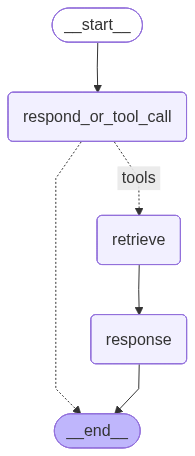

In [2]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
from langchain.messages import HumanMessage
from src.ragState import RAGState
init_state = RAGState(messages = [HumanMessage(content='Hi')],
         documents=None,
         answer=None)
output = graph.invoke(input = init_state)

In [6]:
output

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='60575267-dd34-48a7-b0cb-418abbe6c5bd'),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 41, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E0nWidLP3b4BapXV3NxI4luS4j0OJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f5649-763f-7203-ab60-9d5f88b1a78f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 10, 'total_tokens': 51, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_

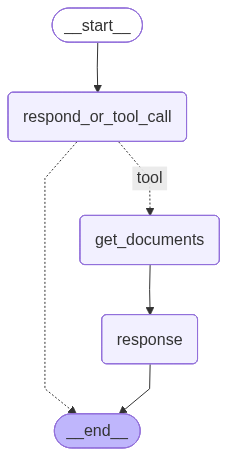

In [1]:
from src.builder import show_graph
from IPython.display import Image, display

display(Image(show_graph()))

In [7]:
from src.builder import run_graph

output = run_graph(query= 'Hi, how are you?')
output

{'messages': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='b3ab8871-198d-4ef5-bbce-581c50ea73f4'),
  AIMessage(content="Hello! I'm here and ready to assist you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 46, 'total_tokens': 65, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E0nXQYgTk5hP2G9WNyZgMgqCPkYre', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f564a-2aa0-7ab3-b8c5-2c7ebf17e8a6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 19, 'total_tokens': 65, 'input_token_det